In [1]:
!pip -q install "pillow<12"
!pip -q install git+https://github.com/facebookresearch/segment-anything.git
!pip -q install transformers accelerate

  Preparing metadata (setup.py) ... done


In [2]:
import os, json, cv2, random, math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F

from google.colab import drive
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
drive.mount("/content/drive")

IMAGE_PATH = "/content/drive/MyDrive/test/d23d55fb7712345c24fa75656be24a49.jpg"

SEGFORMER_MODEL_DIR = "/content/drive/MyDrive/segformer_room_struct/final"

SAM_CHECKPOINT = "/content/drive/MyDrive/models/sam_vit_h_4b8939.pth"
SAM_MODEL_TYPE = "vit_h"

OUT_DIR = "/content/output_furniture_masks"

os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"
assert os.path.exists(SEGFORMER_MODEL_DIR), f"SegFormer folder not found: {SEGFORMER_MODEL_DIR}"
assert os.path.exists(SAM_CHECKPOINT), f"SAM checkpoint not found: {SAM_CHECKPOINT}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
config_path = os.path.join(SEGFORMER_MODEL_DIR, "config.json")

with open(config_path, "r", encoding="utf-8") as f:
    room_cfg = json.load(f)

id2label = {int(k): v for k, v in room_cfg["id2label"].items()}
label2id = {k: int(v) for k, v in room_cfg["label2id"].items()}

print("Classes:")
for k, v in id2label.items():
    print(k, ":", v)

seg_processor = SegformerImageProcessor.from_pretrained(SEGFORMER_MODEL_DIR)
seg_model = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_MODEL_DIR).to(DEVICE)
seg_model.eval()

print("SegFormer loaded.")

Classes:
0 : background
1 : wall
2 : floor
3 : ceiling


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegFormer loaded.


In [5]:
sam_model = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam_model.to(device=DEVICE)
sam_model.eval()

print("SAM loaded.")

SAM loaded.


In [6]:
@torch.no_grad()
def predict_segformer_probs(image_path):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    inputs = seg_processor(images=image, return_tensors="pt").to(DEVICE)
    outputs = seg_model(**inputs)

    logits = F.interpolate(
        outputs.logits,
        size=image_np.shape[:2],
        mode="bilinear",
        align_corners=False
    )

    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred = probs.argmax(axis=0).astype(np.uint8)

    return image_np, pred, probs


def mask_iou(a, b):
    a = a.astype(bool)
    b = b.astype(bool)

    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()

    return float(inter / union) if union > 0 else 0.0


def bbox_from_binary(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    return [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]


def classify_sam_mask(mask, probs, pred):
    mask_bool = mask.astype(bool)
    area = int(mask_bool.sum())

    if area == 0:
        return None

    furniture_probs = probs[FURNITURE_CLASS_IDS]
    surface_probs = probs[ROOM_SURFACE_IDS]

    furniture_max = furniture_probs.max(axis=0)
    surface_max = surface_probs.max(axis=0)

    furniture_mean = float(furniture_max[mask_bool].mean())
    surface_mean = float(surface_max[mask_bool].mean())
    furniture_ratio = float((furniture_max[mask_bool] > surface_max[mask_bool]).mean())

    hard_labels = pred[mask_bool]
    furniture_labels = hard_labels[np.isin(hard_labels, FURNITURE_CLASS_IDS)]

    if len(furniture_labels) > 0:
        values, counts = np.unique(furniture_labels, return_counts=True)
        best_class_id = int(values[np.argmax(counts)])
    else:
        per_cls_mean = [float(probs[cid][mask_bool].mean()) for cid in FURNITURE_CLASS_IDS]
        best_class_id = int(FURNITURE_CLASS_IDS[int(np.argmax(per_cls_mean))])

    return {
        "area": area,
        "furniture_mean": furniture_mean,
        "surface_mean": surface_mean,
        "furniture_ratio": furniture_ratio,
        "best_class_id": best_class_id,
        "best_class_name": id2label[best_class_id],
        "best_class_mean": float(probs[best_class_id][mask_bool].mean()),
    }

In [7]:
def filter_sam_masks(sam_masks, probs, pred, image_shape):
    H, W = image_shape[:2]
    img_area = H * W
    candidates = []

    for idx, item in enumerate(sam_masks):
        seg = item["segmentation"].astype(np.uint8)
        area = int(seg.sum())
        area_ratio = area / img_area

        if area < OBJECT_FILTER_CONFIG["min_area_pixels"]:
            continue

        if area_ratio > OBJECT_FILTER_CONFIG["max_area_ratio"]:
            continue

        sem = classify_sam_mask(seg, probs, pred)

        if sem is None:
            continue

        if sem["furniture_mean"] < OBJECT_FILTER_CONFIG["min_furniture_mean"]:
            continue

        if sem["furniture_ratio"] < OBJECT_FILTER_CONFIG["min_furniture_ratio"]:
            continue

        if sem["surface_mean"] > OBJECT_FILTER_CONFIG["max_surface_mean"]:
            continue

        pred_iou = float(item.get("predicted_iou", 0.0))
        stability = float(item.get("stability_score", 0.0))

        score = (
            1.20 * sem["furniture_mean"] +
            0.75 * sem["furniture_ratio"] +
            0.25 * sem["best_class_mean"] +
            0.20 * pred_iou +
            0.15 * stability -
            0.65 * sem["surface_mean"]
        )

        candidates.append({
            "index": idx,
            "mask": seg,
            "bbox": bbox_from_binary(seg),
            "area": area,
            "area_ratio": float(area_ratio),
            "sam_pred_iou": pred_iou,
            "sam_stability": stability,
            "score": float(score),
            **sem
        })

    return sorted(candidates, key=lambda x: x["score"], reverse=True)


def nms_masks(candidates):
    kept = []

    for cand in candidates:
        duplicate = False

        for old in kept:
            if mask_iou(cand["mask"], old["mask"]) > OBJECT_FILTER_CONFIG["nms_iou"]:
                duplicate = True
                break

        if not duplicate:
            kept.append(cand)

        if len(kept) >= OBJECT_FILTER_CONFIG["keep_top_k"]:
            break

    return kept


def make_union_mask(objects, image_shape):
    H, W = image_shape[:2]

    union_mask = np.zeros((H, W), dtype=np.uint8)
    instance_map = np.zeros((H, W), dtype=np.uint16)

    metadata = []
    class_counter = {}

    for obj_id, obj in enumerate(objects, start=1):
        cls_name = obj["best_class_name"]
        class_counter[cls_name] = class_counter.get(cls_name, 0) + 1
        instance_name = f"{cls_name}_{class_counter[cls_name]}"

        m = obj["mask"].astype(bool)

        union_mask[m] = 255
        instance_map[m] = obj_id

        metadata.append({
            "object_id": obj_id,
            "name": instance_name,
            "class_id": obj["best_class_id"],
            "class_name": cls_name,
            "bbox_xyxy": obj["bbox"],
            "area": int(obj["area"]),
            "area_ratio": float(obj["area_ratio"]),
            "score": float(obj["score"]),
            "furniture_mean": float(obj["furniture_mean"]),
            "furniture_ratio": float(obj["furniture_ratio"]),
            "surface_mean": float(obj["surface_mean"]),
        })

    return union_mask, instance_map, metadata

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Unique class ids: [0 1 2 3]


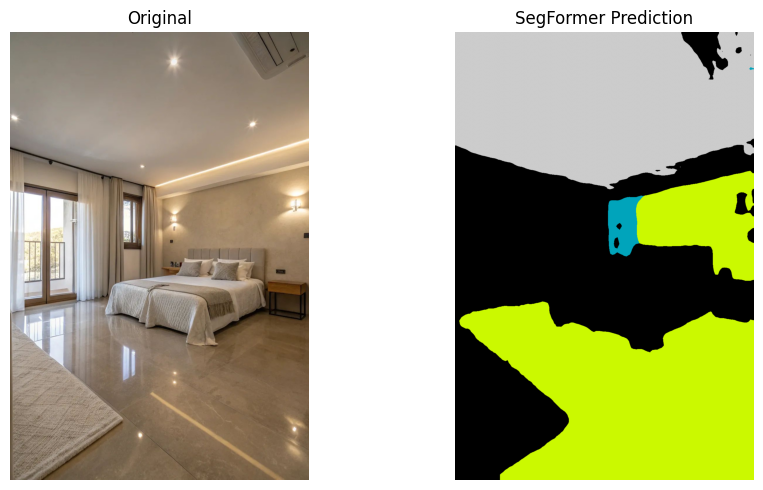

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


image = Image.open(IMAGE_PATH).convert("RGB")
image_np = np.array(image)

SEGFORMER_MODEL="/content/drive/MyDrive/segformer_room_struct/final"
processor = SegformerImageProcessor.from_pretrained(SEGFORMER_MODEL)
model = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_MODEL).to(DEVICE)
model.eval()

inputs = processor(images=image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits  # (B, C, H, W)



upsampled_logits = F.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)


pred = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

print("Unique class ids:", np.unique(pred))



plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred, cmap="nipy_spectral")
plt.title("SegFormer Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

Number of boxes: 3
Boxes: [[0, 909, 1023, 1535], [509, 461, 1023, 868], [0, 0, 1023, 554]]
Saved SAM mask: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_sam_from_segformer_boxes.png


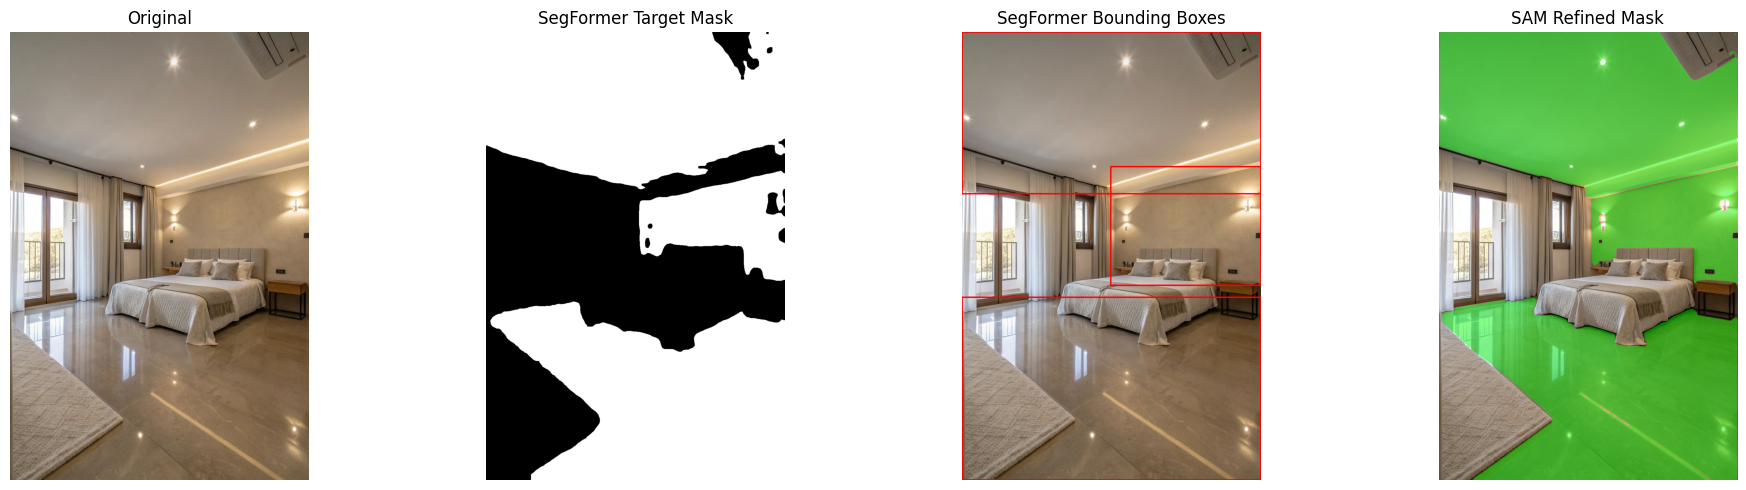

In [9]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from segment_anything import sam_model_registry, SamPredictor


SAM_CHECKPOINT = "/content/drive/MyDrive/ceramic_LoRa/models/sam/sam_vit_l_0b3195.pth"
SAM_MODEL_TYPE = "vit_l"   # vit_b / vit_l / vit_h

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

image = Image.open(IMAGE_PATH).convert("RGB")
image_np = np.array(image)

seg = pred.copy()


sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE)

sam_predictor = SamPredictor(sam)
sam_predictor.set_image(image_np)


def mask_to_boxes(binary_mask, min_area=1500, expand=12):
    h, w = binary_mask.shape

    mask_u8 = (binary_mask > 0).astype(np.uint8) * 255

    contours, _ = cv2.findContours(
        mask_u8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)

        x1 = max(0, x - expand)
        y1 = max(0, y - expand)
        x2 = min(w - 1, x + bw + expand)
        y2 = min(h - 1, y + bh + expand)

        boxes.append([x1, y1, x2, y2])

    return boxes


WALL_ID = label2id.get("wall", 1)
FLOOR_ID = label2id.get("floor", 2)
CEILING_ID = label2id.get("ceiling", 3)

wall_mask = (seg == WALL_ID).astype(np.uint8)
floor_mask = (seg == FLOOR_ID).astype(np.uint8)
ceiling_mask = (seg == CEILING_ID).astype(np.uint8)


target_mask = wall_mask | floor_mask | ceiling_mask

target_mask = cv2.morphologyEx(
    target_mask.astype(np.uint8),
    cv2.MORPH_CLOSE,
    np.ones((7, 7), np.uint8),
    iterations=1
)



boxes = mask_to_boxes(
    target_mask,
    min_area=2000,
    expand=15
)

print("Number of boxes:", len(boxes))
print("Boxes:", boxes)


sam_masks = []

for box in boxes:
    box_np = np.array(box)

    masks, scores, logits = sam_predictor.predict(
        box=box_np,
        multimask_output=True
    )

    best_idx = np.argmax(scores)
    best_mask = masks[best_idx].astype(np.uint8)

    sam_masks.append(best_mask)


if len(sam_masks) > 0:
    final_sam_mask = np.zeros(seg.shape, dtype=np.uint8)

    for m in sam_masks:
        final_sam_mask = np.maximum(final_sam_mask, m)

    final_sam_mask = final_sam_mask * 255
else:
    final_sam_mask = np.zeros(seg.shape, dtype=np.uint8)

base = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

SAM_MASK_PATH = os.path.join(
    OUT_DIR,
    f"{base}_sam_from_segformer_boxes.png"
)

Image.fromarray(final_sam_mask).save(SAM_MASK_PATH)

print("Saved SAM mask:", SAM_MASK_PATH)

box_vis = image_np.copy()

for box in boxes:
    x1, y1, x2, y2 = box
    cv2.rectangle(
        box_vis,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

sam_overlay = image_np.copy()
sam_overlay[final_sam_mask > 0] = (
    0.55 * sam_overlay[final_sam_mask > 0] +
    0.45 * np.array([0, 255, 0])
).astype(np.uint8)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(target_mask, cmap="gray")
plt.title("SegFormer Target Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(box_vis)
plt.title("SegFormer Bounding Boxes")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(sam_overlay)
plt.title("SAM Refined Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Saved SAM protected mask: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_sam_protected_wall_floor_ceiling.png
Saved final remove mask: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_remove_everything_except_sam_surfaces.png


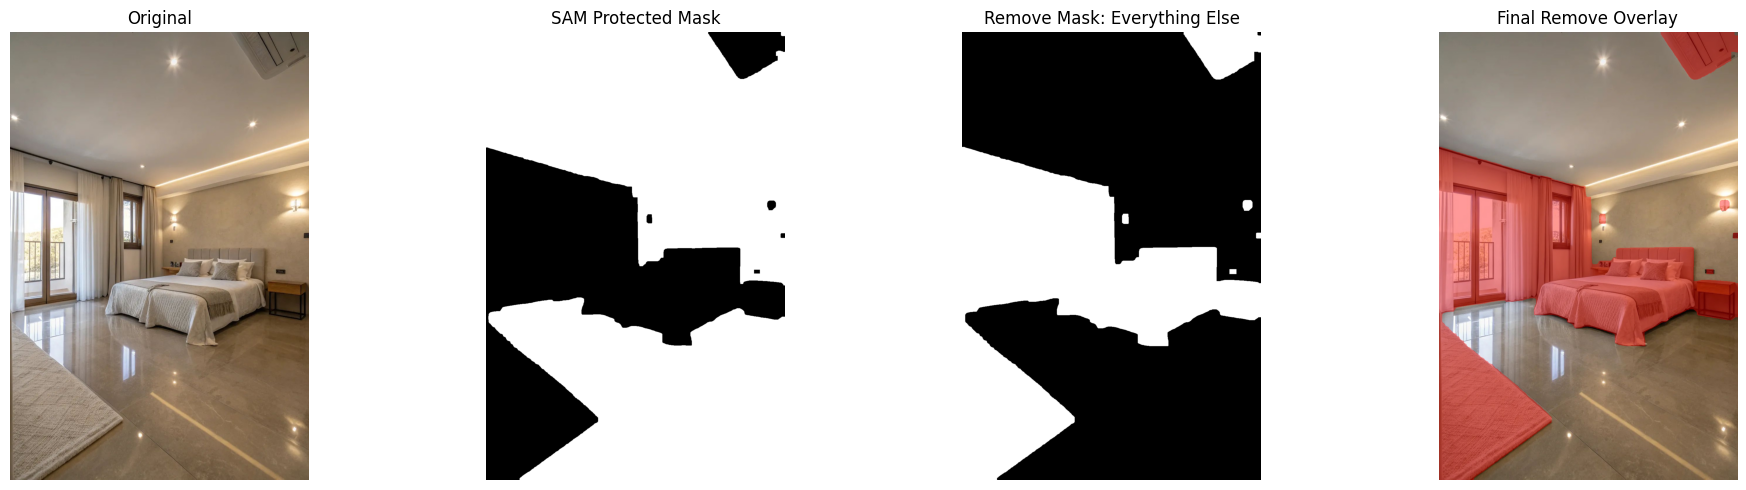

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sam_protected_mask = (final_sam_mask > 0).astype(np.uint8) * 255

sam_protected_mask = cv2.morphologyEx(
    sam_protected_mask,
    cv2.MORPH_CLOSE,
    np.ones((9, 9), np.uint8),
    iterations=2
)

sam_protected_mask = cv2.morphologyEx(
    sam_protected_mask,
    cv2.MORPH_OPEN,
    np.ones((5, 5), np.uint8),
    iterations=1
)

sam_protected_mask = cv2.dilate(
    sam_protected_mask,
    np.ones((5, 5), np.uint8),
    iterations=1
)


remove_everything_else_mask = (sam_protected_mask == 0).astype(np.uint8) * 255


remove_everything_else_mask = cv2.morphologyEx(
    remove_everything_else_mask,
    cv2.MORPH_OPEN,
    np.ones((3, 3), np.uint8),
    iterations=1
)

remove_everything_else_mask = cv2.morphologyEx(
    remove_everything_else_mask,
    cv2.MORPH_CLOSE,
    np.ones((9, 9), np.uint8),
    iterations=2
)

remove_everything_else_mask = cv2.dilate(
    remove_everything_else_mask,
    np.ones((5, 5), np.uint8),
    iterations=1
)


base = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

SAM_PROTECTED_MASK_PATH = os.path.join(
    OUT_DIR,
    f"{base}_sam_protected_wall_floor_ceiling.png"
)

FINAL_REMOVE_MASK_PATH = os.path.join(
    OUT_DIR,
    f"{base}_remove_everything_except_sam_surfaces.png"
)

Image.fromarray(sam_protected_mask).save(SAM_PROTECTED_MASK_PATH)
Image.fromarray(remove_everything_else_mask).save(FINAL_REMOVE_MASK_PATH)

print("Saved SAM protected mask:", SAM_PROTECTED_MASK_PATH)
print("Saved final remove mask:", FINAL_REMOVE_MASK_PATH)

FINAL_MASK_PATH = FINAL_REMOVE_MASK_PATH

protected_overlay = image_np.copy()
protected_overlay[sam_protected_mask > 0] = (
    0.6 * protected_overlay[sam_protected_mask > 0] +
    0.4 * np.array([0, 255, 0])
).astype(np.uint8)

remove_overlay = image_np.copy()
remove_overlay[remove_everything_else_mask > 0] = (
    0.6 * remove_overlay[remove_everything_else_mask > 0] +
    0.4 * np.array([255, 0, 0])
).astype(np.uint8)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(sam_protected_mask, cmap="gray")
plt.title("SAM Protected Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(remove_everything_else_mask, cmap="gray")
plt.title("Remove Mask: Everything Else")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(remove_overlay)
plt.title("Final Remove Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Using FINAL_MASK_PATH: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_remove_everything_except_sam_surfaces.png
Saved input: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_input_512_center_crop.png
Saved mask: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_final_sam_remove_mask_512_center_crop.png


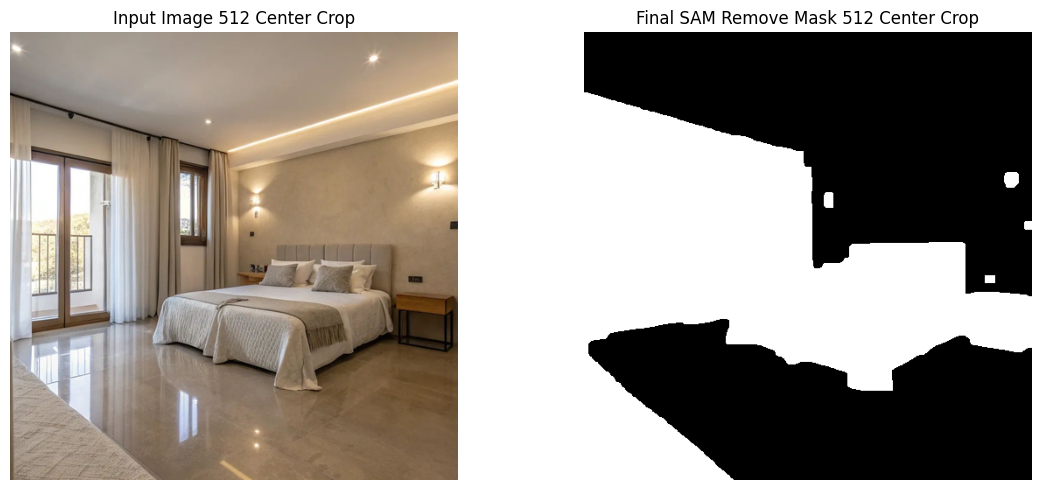

In [19]:
import os
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

INPAINT_SIZE = 512

base = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

FINAL_MASK_PATH = os.path.join(
    OUT_DIR,
    f"{base}_remove_everything_except_sam_surfaces.png"
)

assert os.path.exists(FINAL_MASK_PATH), f"Final SAM remove mask not found: {FINAL_MASK_PATH}"


def center_crop_pil(img: Image.Image, size=512, is_mask=False):
    w, h = img.size

    scale = size / min(w, h)
    new_w, new_h = int(w * scale), int(h * scale)

    resample = Image.NEAREST if is_mask else Image.LANCZOS
    img_resized = img.resize((new_w, new_h), resample)

    left = (new_w - size) // 2
    top = (new_h - size) // 2

    return img_resized.crop((left, top, left + size, top + size))


original_image = Image.open(IMAGE_PATH).convert("RGB")
final_remove_mask = Image.open(FINAL_MASK_PATH).convert("L")

init_image = center_crop_pil(
    original_image,
    size=INPAINT_SIZE,
    is_mask=False
)

mask_image = center_crop_pil(
    final_remove_mask,
    size=INPAINT_SIZE,
    is_mask=True
)

INPUT_512_PATH = os.path.join(OUT_DIR, f"{base}_input_512_center_crop.png")
MASK_512_PATH = os.path.join(OUT_DIR, f"{base}_final_sam_remove_mask_512_center_crop.png")

init_image.save(INPUT_512_PATH)
mask_image.save(MASK_512_PATH)

print("Using FINAL_MASK_PATH:", FINAL_MASK_PATH)
print("Saved input:", INPUT_512_PATH)
print("Saved mask:", MASK_512_PATH)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Input Image 512 Center Crop")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Final SAM Remove Mask 512 Center Crop")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
%cd /content

!git clone https://github.com/DepthAnything/Depth-Anything-V2.git

%cd /content/Depth-Anything-V2
!pip -q install -r requirements.txt

/content
fatal: destination path 'Depth-Anything-V2' already exists and is not an empty directory.
/content/Depth-Anything-V2


In [13]:
import os, sys, importlib

REPO = "/content/Depth-Anything-V2"
PKG  = "/content/Depth-Anything-V2/depth_anything_v2"

print("REPO exists:", os.path.exists(REPO))
print("PKG exists:", os.path.exists(PKG))
print("PKG files:", os.listdir(PKG))


sys.path = [p for p in sys.path if "Depth-Anything-V2" not in p]


sys.path.insert(0, REPO)


open(os.path.join(PKG, "__init__.py"), "a").close()


for m in list(sys.modules.keys()):
    if m.startswith("depth_anything_v2"):
        del sys.modules[m]

importlib.invalidate_caches()

print("sys.path[0]:", sys.path[0])

from depth_anything_v2.dpt import DepthAnythingV2

print(" Import successful")

REPO exists: True
PKG exists: True
PKG files: ['dinov2_layers', 'dinov2.py', 'util', '__pycache__', '__init__.py', 'dpt.py']
sys.path[0]: /content/Depth-Anything-V2
 Import successful


In [14]:
import torch, cv2, os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CHECKPOINT = "/content/drive/MyDrive/models/depth_anything_v2_vitl.pth"
encoder = "vitl"

model_configs = {
    "vits": {"encoder": "vits", "features": 64, "out_channels": [48, 96, 192, 384]},
    "vitb": {"encoder": "vitb", "features": 128, "out_channels": [96, 192, 384, 768]},
    "vitl": {"encoder": "vitl", "features": 256, "out_channels": [256, 512, 1024, 1024]},
}

depth_model = DepthAnythingV2(**model_configs[encoder])

state = torch.load(DEPTH_CHECKPOINT, map_location="cpu")
depth_model.load_state_dict(state)

depth_model = depth_model.to(DEVICE).eval()

print("Depth model loaded")

Depth model loaded


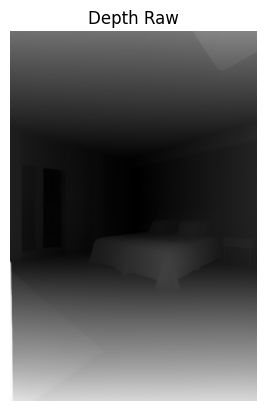

Saved: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_depth_raw.png


In [15]:
raw_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

with torch.no_grad():
    depth = depth_model.infer_image(raw_bgr)

depth_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
depth_uint8 = (depth_norm * 255).astype(np.uint8)

depth_raw = Image.fromarray(depth_uint8).convert("RGB")

DEPTH_PATH = os.path.join(OUT_DIR, f"{base}_depth_raw.png")
depth_raw.save(DEPTH_PATH)

plt.imshow(depth_raw, cmap="gray")
plt.title("Depth Raw")
plt.axis("off")
plt.show()

print("Saved:", DEPTH_PATH)

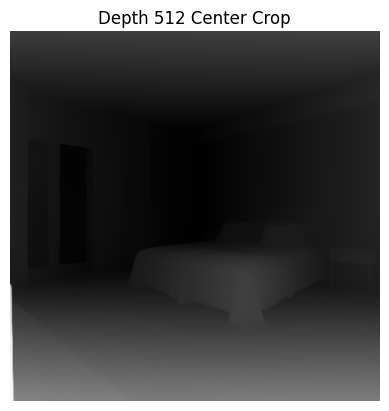

Saved: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_depth_512_center_crop.png


In [20]:
depth_img = center_crop_pil(
    depth_raw.convert("RGB"),
    size=INPAINT_SIZE,
    is_mask=False
)

DEPTH_512_PATH = os.path.join(OUT_DIR, f"{base}_depth_512_center_crop.png")
depth_img.save(DEPTH_512_PATH)

plt.imshow(depth_img)
plt.title("Depth 512 Center Crop")
plt.axis("off")
plt.show()

print("Saved:", DEPTH_512_PATH)

In [17]:
import torch, os
from diffusers import (
    StableDiffusionControlNetInpaintPipeline,
    ControlNetModel,
    UniPCMultistepScheduler
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11f1p_sd15_depth",
    torch_dtype=DTYPE
)

pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    controlnet=controlnet,
    torch_dtype=DTYPE,
    safety_checker=None
)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

if DEVICE == "cuda":
    pipe.enable_model_cpu_offload()
    pipe.enable_attention_slicing()
else:
    pipe = pipe.to(DEVICE)

print("Pipeline ready")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.

Pipeline ready


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['baskets , ceramic lamps , jute rug , warm earthy tones , terracotta , beige , cream , olive , very strong transformation , new bedroom furniture shapes , photorealistic , realistic lighting , realistic shadows , high detail , preserve unmasked walls , preserve unmasked floor , preserve ceiling , preserve windows']


Running: boho_super


  0%|          | 0/43 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', black , chrome accents , clean lines , high - end hotel bedroom interior , strong contemporary transformation , photorealistic , realistic lighting , realistic shadows , high detail , preserve unmasked walls , preserve unmasked floor , preserve ceiling , preserve windows']


Saved: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_boho_super_bedroom_strong_result.png
Running: modern_luxury_super


...

  0%|          | 0/43 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['bedroom layout , warm elegant lighting , velvet , carved wood , marble and gold accents , cream and champagne tones , photorealistic , realistic lighting , high detail , preserve unmasked walls , preserve unmasked floor , preserve ceiling , preserve windows']


Saved: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_industrial_super_bedroom_strong_result.png
Running: classic_luxury_super


  0%|          | 0/43 [00:00<?, ?it/s]

Saved: /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_classic_luxury_super_bedroom_strong_result.png


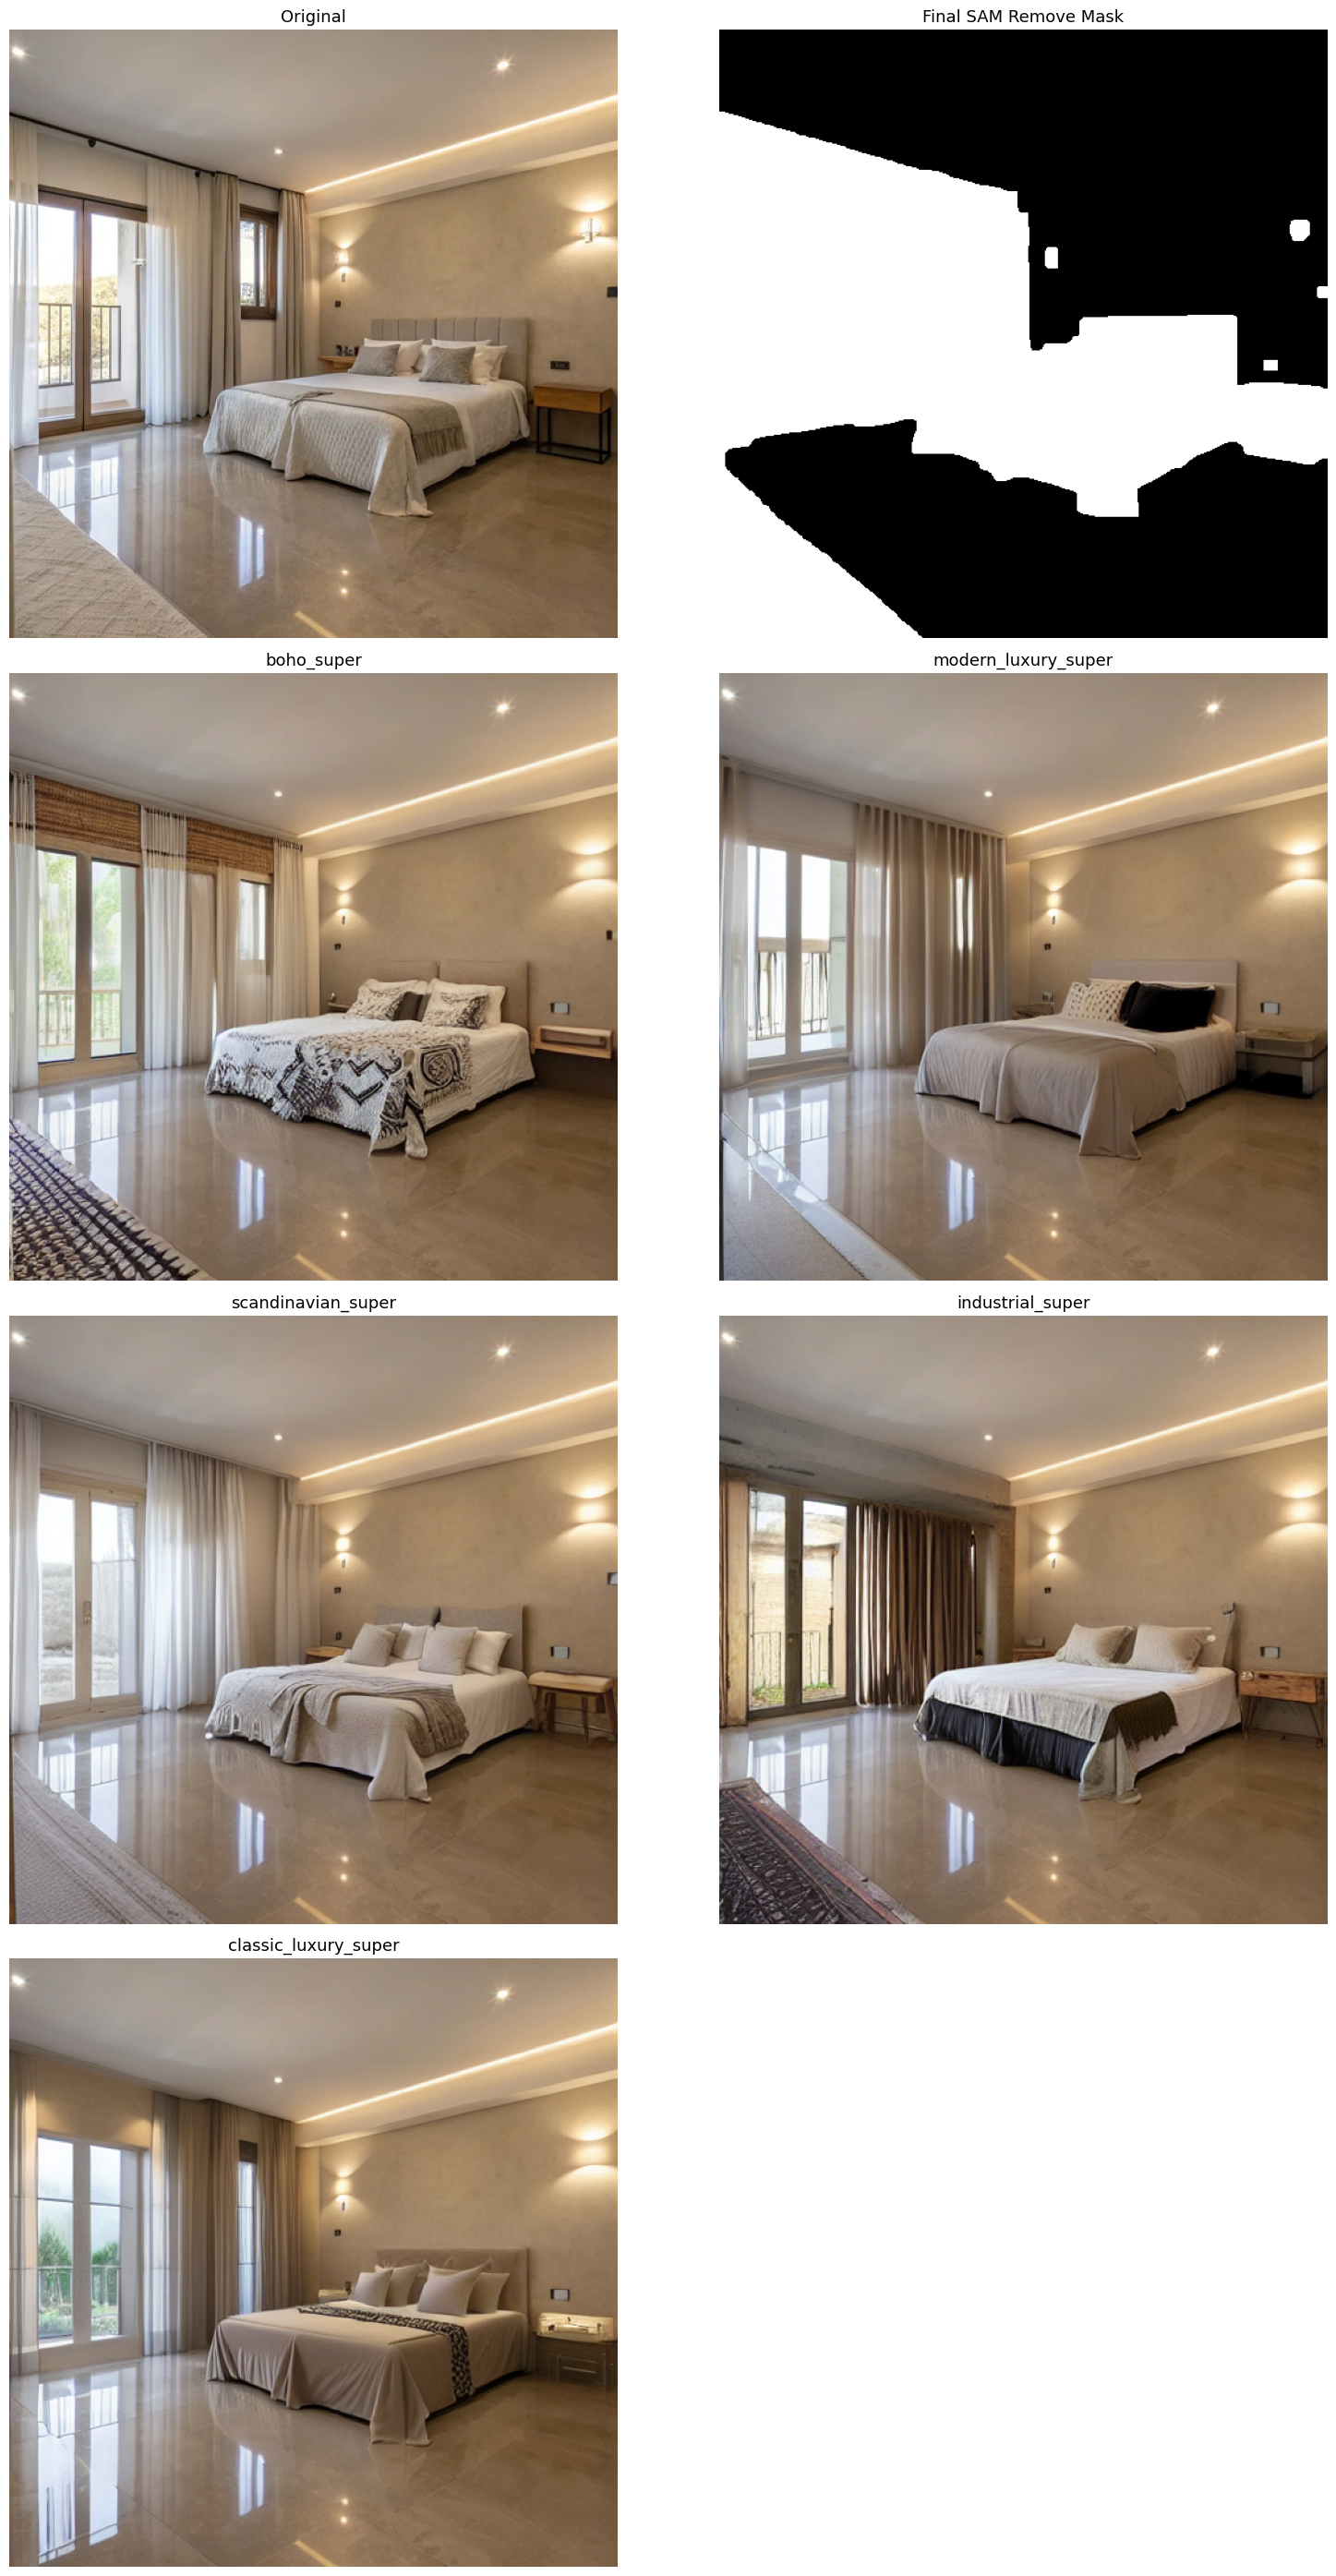


Saved results:
boho_super : /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_boho_super_bedroom_strong_result.png
modern_luxury_super : /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_modern_luxury_super_bedroom_strong_result.png
scandinavian_super : /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_scandinavian_super_bedroom_strong_result.png
industrial_super : /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_industrial_super_bedroom_strong_result.png
classic_luxury_super : /content/output_furniture_masks/d23d55fb7712345c24fa75656be24a49_classic_luxury_super_bedroom_strong_result.png


In [21]:
import os
import math
import torch
import matplotlib.pyplot as plt

assert "pipe" in globals(), "StableDiffusionControlNetInpaintPipeline not loaded"
assert "depth_img" in globals(), "depth_img is missing"
assert "mask_image" in globals(), "mask_image is missing"
assert "init_image" in globals(), "init_image is missing"

STYLE_PRESETS = {
    "boho_super": {
        "prompt": (
            "radical boho bedroom interior transformation, "
            "completely replace all masked bedroom furniture and decor, "
            "(remove original bed completely:1.6), "
            "(remove all existing furniture:1.6), "
            "do not keep original furniture, "
            "new rattan bed frame with woven headboard, organic wooden nightstands, "
            "layered patterned bedding, linen pillows, floor cushions, "
            "macrame wall hanging, indoor plants, woven baskets, ceramic lamps, "
            "jute rug, warm earthy tones, terracotta, beige, cream, olive, "
            "very strong transformation, new bedroom furniture shapes, "
            "photorealistic, realistic lighting, realistic shadows, high detail, "
            "preserve unmasked walls, preserve unmasked floor, preserve ceiling, preserve windows"
        ),
        "negative": (
            "living room, sofa, lounge chair, coffee table, "
            "same bed, original bed, unchanged bed, unchanged nightstand, "
            "same furniture, unchanged furniture, only color change, weak transformation, "
            "minimal edit, blurry, artifacts"
        )
    },

    "modern_luxury_super": {
        "prompt": (
            "radical modern luxury bedroom redesign, "
            "completely replace all masked bedroom furniture and decor, "
            "(remove original bed completely:1.6), "
            "(remove all existing furniture:1.6), "
            "do not keep original furniture, "
            "sleek low-profile platform bed, upholstered headboard, modern nightstands, "
            "premium bedding, hidden warm LED lighting, abstract wall decor, "
            "ivory, taupe, gray, black, chrome accents, clean lines, "
            "high-end hotel bedroom interior, strong contemporary transformation, "
            "photorealistic, realistic lighting, realistic shadows, high detail, "
            "preserve unmasked walls, preserve unmasked floor, preserve ceiling, preserve windows"
        ),
        "negative": (
            "living room, sofa, coffee table, same bed, original bed, unchanged bed, "
            "same furniture, unchanged furniture, weak change, color change only, "
            "clutter, blurry, artifacts"
        )
    },

    "scandinavian_super": {
        "prompt": (
            "strong scandinavian nordic bedroom transformation, "
            "completely replace all masked bedroom furniture and decor, "
            "(remove original bed completely:1.6), "
            "(remove all existing furniture:1.6), "
            "do not keep original furniture, "
            "light beige fabric bed with wooden legs, light oak nightstands, "
            "soft wool blanket, linen pillows, subtle ceramic lamp, small green plants, "
            "bright airy daylight, white, cream, pale gray, natural light wood, "
            "clean cozy hygge bedroom layout, calm balanced composition, "
            "photorealistic, realistic shadows, high detail, "
            "preserve unmasked walls, preserve unmasked floor, preserve ceiling, preserve windows"
        ),
        "negative": (
            "living room, sofa, coffee table, same bed, original bed, unchanged bed, "
            "same furniture, unchanged furniture, dark industrial interior, clutter, "
            "weak transformation, blurry, artifacts"
        )
    },

    "industrial_super": {
        "prompt": (
            "radical industrial bedroom redesign, "
            "completely replace all masked bedroom furniture and decor, "
            "(remove original bed completely:1.6), "
            "(remove all existing furniture:1.6), "
            "do not keep original furniture, "
            "dark leather bed frame, black steel frame nightstands, reclaimed wood headboard, "
            "vintage factory lamps, concrete decor, dark shelves, aged leather, raw wood, "
            "black steel, dark matte finishes, urban loft bedroom atmosphere, "
            "dramatic contrast lighting, strong transformation, photorealistic, high detail, "
            "preserve unmasked walls, preserve unmasked floor, preserve ceiling, preserve windows"
        ),
        "negative": (
            "living room, sofa, coffee table, same bed, original bed, unchanged bed, "
            "same furniture, unchanged furniture, soft scandinavian, pastel colors, "
            "boho decor, blurry, artifacts"
        )
    },

    "classic_luxury_super": {
        "prompt": (
            "radical luxury classic bedroom redesign, "
            "completely replace all masked bedroom furniture and decor, "
            "(remove original bed completely:1.6), "
            "(remove all existing furniture:1.6), "
            "do not keep original furniture, "
            "ornate upholstered bed frame, carved wooden headboard, classic nightstands, "
            "luxury bedding, elegant table lamps, decorative vases, palace-inspired decor, "
            "symmetrical refined bedroom layout, warm elegant lighting, velvet, carved wood, "
            "marble and gold accents, cream and champagne tones, "
            "photorealistic, realistic lighting, high detail, "
            "preserve unmasked walls, preserve unmasked floor, preserve ceiling, preserve windows"
        ),
        "negative": (
            "living room, sofa, coffee table, same bed, original bed, unchanged bed, "
            "same furniture, unchanged furniture, modern minimal furniture, industrial metal, "
            "cheap furniture, blurry, artifacts"
        )
    }
}

GLOBAL_NEGATIVE = (
    "living room, sofa, lounge chair, coffee table, "
    "same furniture, unchanged furniture, same bed, unchanged bed, original bed, "
    "same nightstand, unchanged nightstand, "
    "only color change, weak transformation, minor edit, subtle change, "
    "distorted room, distorted perspective, broken geometry, deformed furniture, "
    "floating objects, duplicated objects, melted objects, extra walls, new windows, "
    "changed unmasked architecture, changed unmasked floor, changed unmasked ceiling, "
    "blurry, low quality, artifacts, noise, oversaturated, cartoon, painting, CGI, "
    "text, watermark, logo"
)

GEN_SETTINGS = {
    "num_inference_steps": 45,
    "guidance_scale": 10.0,
    "strength": 0.97,
    "controlnet_conditioning_scale": 0.65,
}

results = []

for idx, (style_name, cfg) in enumerate(STYLE_PRESETS.items()):
    print("=" * 80)
    print("Running:", style_name)

    prompt = cfg["prompt"]
    negative_prompt = GLOBAL_NEGATIVE + ", " + cfg["negative"]

    generator = torch.Generator(device=DEVICE).manual_seed(777 + idx)

    with torch.no_grad():
        result = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=init_image,
            mask_image=mask_image,
            control_image=depth_img,
            num_inference_steps=GEN_SETTINGS["num_inference_steps"],
            guidance_scale=GEN_SETTINGS["guidance_scale"],
            strength=GEN_SETTINGS["strength"],
            controlnet_conditioning_scale=GEN_SETTINGS["controlnet_conditioning_scale"],
            generator=generator
        ).images[0]

    RESULT_PATH = os.path.join(
        OUT_DIR,
        f"{base}_{style_name}_bedroom_strong_result.png"
    )

    result.save(RESULT_PATH)
    print("Saved:", RESULT_PATH)

    results.append((style_name, result, RESULT_PATH))

display_items = [
    ("Original", init_image),
    ("Final SAM Remove Mask", mask_image),
] + [(name, img) for name, img, path in results]

cols = 2
rows = math.ceil(len(display_items) / cols)

plt.figure(figsize=(16, 7 * rows))

for i, (title, img) in enumerate(display_items, 1):
    plt.subplot(rows, cols, i)

    if "Mask" in title:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)

    plt.title(title, fontsize=13)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("\nSaved results:")
for name, img, path in results:
    print(name, ":", path)